
# Solución completa del taller: inferencia bivariada con $\Sigma$ conocida

**Curso:** Profundización en Estadística para Científicos de Datos  
**Formato:** Notebook autocontenido para Google Colab  
**Tema:** solución detallada, paso a paso, de los ejercicios propuestos sobre inferencia bivariada

---

## Objetivo

En este notebook resolvemos completamente el taller propuesto sobre:

- prueba de hipótesis multivariada con $\Sigma$ conocida,
- región de confianza conjunta,
- efecto del tamaño muestral,
- consecuencias de ignorar la covarianza,
- caso con $\Sigma$ desconocida mediante $T^2$ de Hotelling,
- derivación conceptual de la forma cuadrática,
- interpretación geométrica de la elipse de confianza.

La idea no es solo obtener números, sino entender con precisión:

1. qué información se necesita,
2. qué fórmula corresponde en cada ejercicio,
3. cómo se interpreta el resultado,
4. y por qué la geometría multivariada es esencial.


In [1]:

# ==========================================
# 1. Librerías
# ==========================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import chi2, f
from matplotlib.patches import Ellipse

plt.rcParams["figure.figsize"] = (8, 6)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 11

np.set_printoptions(precision=6, suppress=True)



## Información numérica que necesitamos para resolver el taller

Para resolver los ejercicios ya contamos con toda la información base del ejemplo del dron.  
La vamos a dejar explícita desde el inicio para que el notebook sea completamente autocontenido.

### Tamaño muestral

$$
n = 30
$$

### Matriz de covarianzas conocida

$$
\Sigma=
\begin{pmatrix}
1.00 & 0.60\\
0.60 & 1.44
\end{pmatrix}
$$

### Muestra observada

La muestra de aterrizajes observada es la siguiente.


In [2]:

# ==========================================
# 2. Datos base del problema
# ==========================================
n = 30

Sigma = np.array([
    [1.00, 0.60],
    [0.60, 1.44]
])

X = np.array([
    [ 0.553560, -3.746761],
    [ 0.578362, -1.065154],
    [ 1.038116,  0.061888],
    [ 2.271987,  1.806762],
    [-0.850952,  2.067421],
    [ 0.594071, -0.756289],
    [ 1.187052, -0.327128],
    [ 1.617986,  0.658912],
    [ 0.322797, -0.992842],
    [-0.072898, -1.507804],
    [-0.434880,  0.297529],
    [ 0.440124, -1.179829],
    [ 0.354989,  0.090284],
    [-0.792299, -2.630755],
    [ 0.113836,  0.359698],
    [ 1.424371,  0.513588],
    [-0.501667, -1.083238],
    [ 0.059821, -0.159844],
    [ 2.119839,  3.257114],
    [ 2.341894, -0.005529],
    [-0.103579, -0.353276],
    [ 1.569858, -0.322608],
    [ 0.562564, -0.402224],
    [-1.014423, -1.595015],
    [-0.295945, -0.081498],
    [ 1.289026, -0.524355],
    [-0.270002, -0.748634],
    [ 1.206878, -0.451503],
    [ 1.929457, -1.694571],
    [-0.295841, -0.906987]
])

df = pd.DataFrame(X, columns=["x", "y"])
df.index = np.arange(1, n + 1)
df


,x,y
1,0.553560,-3.746761
2,0.578362,-1.065154
3,1.038116,0.061888
4,2.271987,1.806762
5,-0.850952,2.067421
6,0.594071,-0.756289
7,1.187052,-0.327128
8,1.617986,0.658912
9,0.322797,-0.992842
10,-0.072898,-1.507804



## Resúmenes muestrales que usaremos repetidamente

A partir de la muestra necesitamos dos objetos fundamentales:

### Media muestral vectorial

$$
\bar{\mathbf Z}
=
\begin{pmatrix}
\bar X\\
\bar Y
\end{pmatrix}
=
\frac{1}{n}\sum_{i=1}^n \mathbf Z_i
$$

### Covarianza muestral

$$
S=\frac{1}{n-1}\sum_{i=1}^n
(\mathbf Z_i-\bar{\mathbf Z})(\mathbf Z_i-\bar{\mathbf Z})^\top
$$

Aunque en el caso de $\Sigma$ conocida la matriz $S$ no entra en el test principal, sí la necesitaremos en el ejercicio de Hotelling.


In [3]:

# ==========================================
# 3. Resúmenes muestrales
# ==========================================
xbar = X.mean(axis=0)
S = np.cov(X.T, ddof=1)

print("Media muestral vectorial:")
print(xbar)

print("\nCovarianza muestral S:")
print(S)


Media muestral vectorial:
[ 0.564803 -0.380755]

Covarianza muestral S:
[[0.925705 0.440725]
 [0.440725 1.759436]]



Conviene dejar estos resultados escritos también de forma explícita:

$$
\bar{\mathbf Z}
=
\begin{pmatrix}
0.564803\\
-0.380755
\end{pmatrix}
$$

y

$$
S \approx
\begin{pmatrix}
0.925705 & 0.440725\\
0.440725 & 1.759437
\end{pmatrix}.
$$

Además, la covarianza de la media muestral es:

$$
\operatorname{Cov}(\bar{\mathbf Z})=\frac{\Sigma}{n}.
$$


In [4]:

# ==========================================
# 4. Utilidades
# ==========================================
def quad_form(mu_candidate, xbar, Sigma, n):
    d = xbar - mu_candidate
    return n * d.T @ np.linalg.inv(Sigma) @ d

def confidence_ellipse_from_cov(mean, cov, level=0.95, ax=None, label=None, **kwargs):
    if ax is None:
        ax = plt.gca()

    c2 = chi2.ppf(level, df=2)

    eigvals, eigvecs = np.linalg.eigh(cov)
    order = eigvals.argsort()[::-1]
    eigvals = eigvals[order]
    eigvecs = eigvecs[:, order]

    width = 2 * np.sqrt(c2 * eigvals[0])
    height = 2 * np.sqrt(c2 * eigvals[1])
    angle = np.degrees(np.arctan2(*eigvecs[:, 0][::-1]))

    ell = Ellipse(
        xy=mean,
        width=width,
        height=height,
        angle=angle,
        fill=False,
        label=label,
        **kwargs
    )
    ax.add_patch(ell)
    return ell

Sigma_bar = Sigma / n
print("Sigma/n =")
print(Sigma_bar)


Sigma/n =
[[0.033333 0.02    ]
 [0.02     0.048   ]]



## Visualización inicial del problema

Antes de entrar a los ejercicios, vemos la nube de aterrizajes, el centro muestral y el origen.


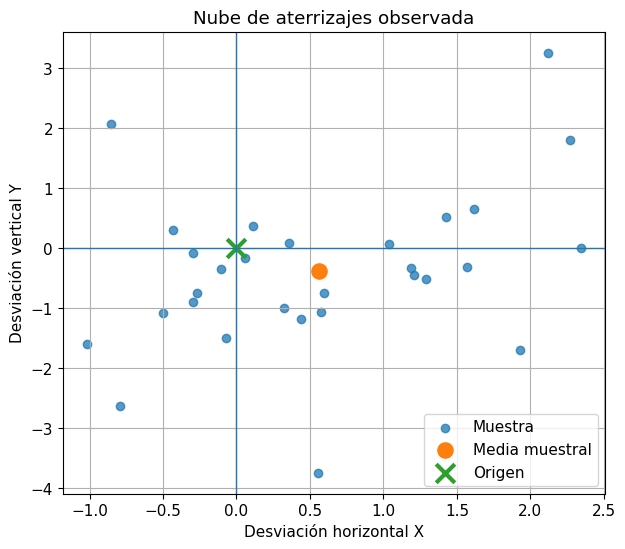

In [5]:

plt.figure(figsize=(7, 6))
plt.scatter(X[:, 0], X[:, 1], alpha=0.75, label="Muestra")
plt.scatter([xbar[0]], [xbar[1]], s=120, label="Media muestral")
plt.scatter([0], [0], marker="x", s=180, linewidths=3, label="Origen")

plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)
plt.xlabel("Desviación horizontal X")
plt.ylabel("Desviación vertical Y")
plt.title("Nube de aterrizajes observada")
plt.legend()
plt.show()



# Ejercicio 1. Repetición completa del ejemplo con otro valor nulo

Se desea contrastar ahora:

$$
H_0:
\boldsymbol{\mu}=
\begin{pmatrix}
0.4\\
-0.2
\end{pmatrix}
\qquad\text{vs}\qquad
H_1:
\boldsymbol{\mu}\neq
\begin{pmatrix}
0.4\\
-0.2
\end{pmatrix}
$$

---

## Paso 1. Estadístico de prueba

Como $\Sigma$ es conocida, el estadístico adecuado es:

$$
T
=
n(\bar{\mathbf Z}-\boldsymbol{\mu}_0)^\top
\Sigma^{-1}
(\bar{\mathbf Z}-\boldsymbol{\mu}_0).
$$

Aquí:

$$
\boldsymbol{\mu}_0=
\begin{pmatrix}
0.4\\
-0.2
\end{pmatrix},
\qquad
\bar{\mathbf Z}=
\begin{pmatrix}
0.564803\\
-0.380755
\end{pmatrix}.
$$

Bajo $H_0$:

$$
T \sim \chi^2_2.
$$


In [6]:

# ==========================================
# Ejercicio 1
# ==========================================
mu0_1 = np.array([0.4, -0.2])

T1 = quad_form(mu0_1, xbar, Sigma, n)
crit_95 = chi2.ppf(0.95, df=2)
pval_1 = 1 - chi2.cdf(T1, df=2)

print(f"mu0 = {mu0_1}")
print(f"T = {T1:.6f}")
print(f"Valor crítico al 5% = {crit_95:.6f}")
print(f"p-value = {pval_1:.6f}")


mu0 = [ 0.4 -0.2]
T = 2.986939
Valor crítico al 5% = 5.991465
p-value = 0.224592



## Paso 2. Región de rechazo al 5%

La regla de rechazo es:

$$
\text{rechazar } H_0
\quad \text{si} \quad
T > \chi^2_{2,0.95}.
$$

Como

$$
\chi^2_{2,0.95}\approx 5.9915,
$$

la región de rechazo es:

$$
\mathcal R
=
\left\{
\bar{\mathbf Z}:
n(\bar{\mathbf Z}-\boldsymbol{\mu}_0)^\top
\Sigma^{-1}
(\bar{\mathbf Z}-\boldsymbol{\mu}_0)
>
5.9915
\right\}.
$$



## Paso 3. Decisión

Numéricamente obtuvimos:

$$
T \approx 2.9869.
$$

Como

$$
2.9869 < 5.9915,
$$

**no se rechaza $H_0$ al 5\%**.

Equivalentemente, el valor-$p$ es aproximadamente:

$$
0.2246,
$$

que es bastante mayor que $0.05$.



## Paso 4. Interpretación en contexto

La muestra observada no ofrece evidencia suficiente para afirmar que el centro verdadero de aterrizaje sea distinto de

$$
(0.4,-0.2).
$$

Ojo con la lectura correcta:

- esto **no prueba** que el centro verdadero sea exactamente $(0.4,-0.2)$,
- solo indica que, con esta muestra y este nivel de significancia, esa hipótesis es compatible con los datos.


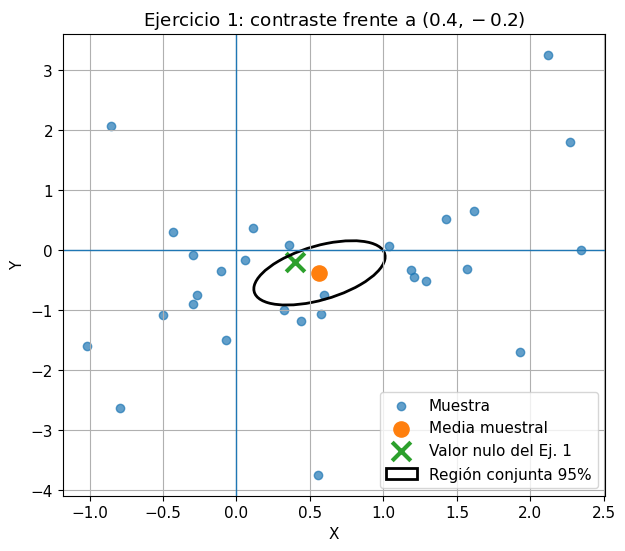

In [7]:

# Visualización del valor nulo del Ejercicio 1
plt.figure(figsize=(7, 6))
ax = plt.gca()

plt.scatter(X[:, 0], X[:, 1], alpha=0.7, label="Muestra")
plt.scatter([xbar[0]], [xbar[1]], s=120, label="Media muestral")
plt.scatter([mu0_1[0]], [mu0_1[1]], marker="x", s=180, linewidths=3, label="Valor nulo del Ej. 1")

confidence_ellipse_from_cov(
    mean=xbar,
    cov=Sigma / n,
    level=0.95,
    ax=ax,
    linewidth=2,
    label="Región conjunta 95%"
)

plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Ejercicio 1: contraste frente a $(0.4,-0.2)$")
plt.legend()
plt.show()



# Ejercicio 2. Región de confianza con otro nivel

Ahora construimos la región de confianza conjunta del $99\%$.

La fórmula general es:

$$
\mathcal C_{1-\alpha}
=
\left\{
\boldsymbol{\mu}:
n(\bar{\mathbf Z}-\boldsymbol{\mu})^\top
\Sigma^{-1}
(\bar{\mathbf Z}-\boldsymbol{\mu})
\le
\chi^2_{2,1-\alpha}
\right\}.
$$

Para el $95\%$ y el $99\%$ los únicos cambios están en el cuantil:

$$
\chi^2_{2,0.95}\approx 5.9915,
\qquad
\chi^2_{2,0.99}\approx 9.2103.
$$


In [8]:

# ==========================================
# Ejercicio 2
# ==========================================
crit_99 = chi2.ppf(0.99, df=2)

print(f"chi2_2,0.95 = {crit_95:.6f}")
print(f"chi2_2,0.99 = {crit_99:.6f}")


chi2_2,0.95 = 5.991465
chi2_2,0.99 = 9.210340



## Comparación conceptual entre la región del 95% y la del 99%

La región del $99\%$ debe ser más grande que la del $95\%$.

La razón es simple pero importante:

- al exigir más confianza,
- queremos cubrir el parámetro verdadero con mayor probabilidad,
- y para lograrlo debemos aceptar una zona de valores posibles más amplia.

En términos de la forma cuadrática, el umbral pasa de $5.9915$ a $9.2103$, así que la elipse se expande.


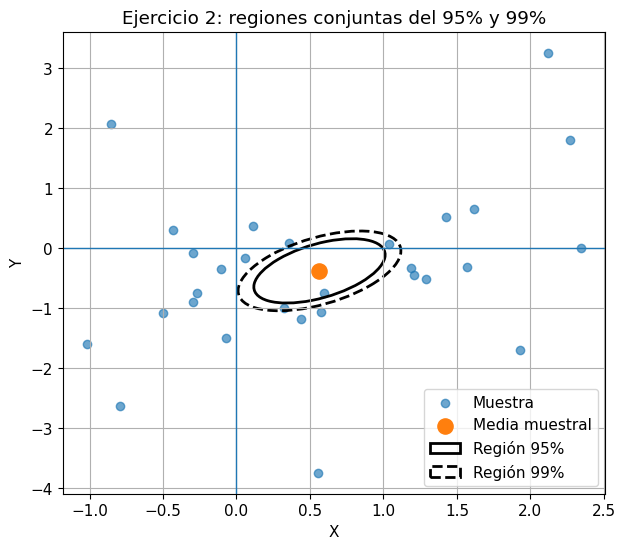

In [9]:

plt.figure(figsize=(7, 6))
ax = plt.gca()

plt.scatter(X[:, 0], X[:, 1], alpha=0.65, label="Muestra")
plt.scatter([xbar[0]], [xbar[1]], s=120, label="Media muestral")

confidence_ellipse_from_cov(
    mean=xbar,
    cov=Sigma / n,
    level=0.95,
    ax=ax,
    linewidth=2,
    label="Región 95%"
)

confidence_ellipse_from_cov(
    mean=xbar,
    cov=Sigma / n,
    level=0.99,
    ax=ax,
    linewidth=2,
    linestyle="--",
    label="Región 99%"
)

plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Ejercicio 2: regiones conjuntas del 95% y 99%")
plt.legend()
plt.show()



## Conclusión del Ejercicio 2

- la región conjunta del $99\%$ es **más grande** que la del $95\%$,
- tiene el mismo centro $\bar{\mathbf Z}$,
- mantiene la misma orientación porque depende de la misma $\Sigma$,
- pero aumenta su tamaño porque el cuantil de referencia es mayor.



# Ejercicio 3. Sensibilidad al tamaño muestral

Se pide comparar qué ocurre cuando cambiamos $n$ y mantenemos fija la misma $\Sigma$ y un centro verdadero no nulo.

Aquí lo importante no es una sola realización aislada, sino la lógica inferencial:

$$
\bar{\mathbf Z}\sim \mathcal N_2\left(\boldsymbol{\mu}, \frac{\Sigma}{n}\right).
$$

Por tanto, cuando $n$ crece, la matriz de covarianzas de $\bar{\mathbf Z}$ disminuye.  
Eso implica que la estimación del centro es más precisa y la elipse de confianza se contrae.


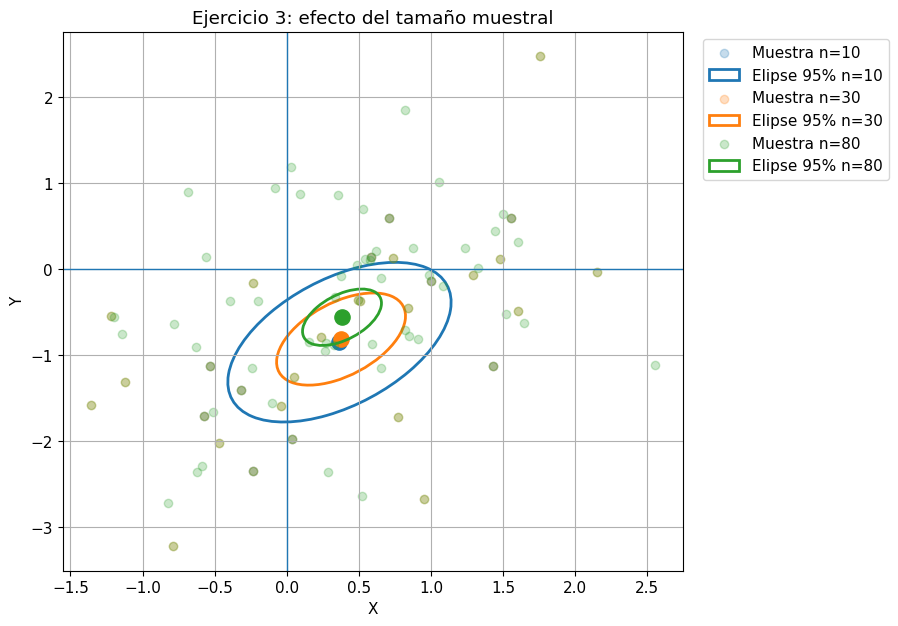

,n,xbar_x,xbar_y
0,10,0.365192,-0.848883
1,30,0.376109,-0.812473
2,80,0.382744,-0.558582


In [10]:

# ==========================================
# Ejercicio 3
# ==========================================
mu_true = np.array([0.55, -0.35])
n_values = [10, 30, 80]

results = []

plt.figure(figsize=(8, 7))
ax = plt.gca()

colors = ["tab:blue", "tab:orange", "tab:green"]

for color, nn in zip(colors, n_values):
    rng = np.random.default_rng(123)  # semilla fija para comparación reproducible
    sample = rng.multivariate_normal(mu_true, Sigma, size=nn)
    xb = sample.mean(axis=0)

    results.append({
        "n": nn,
        "xbar_x": xb[0],
        "xbar_y": xb[1]
    })

    plt.scatter(sample[:, 0], sample[:, 1], alpha=0.25, color=color, label=f"Muestra n={nn}")
    plt.scatter([xb[0]], [xb[1]], s=120, color=color)

    confidence_ellipse_from_cov(
        mean=xb,
        cov=Sigma/nn,
        level=0.95,
        ax=ax,
        linewidth=2,
        edgecolor=color,
        label=f"Elipse 95% n={nn}"
    )

plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Ejercicio 3: efecto del tamaño muestral")
plt.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0))
plt.show()

pd.DataFrame(results)



## Explicación detallada

La región conjunta del $95\%$ está dada por

$$
n(\bar{\mathbf Z}-\boldsymbol{\mu})^\top
\Sigma^{-1}
(\bar{\mathbf Z}-\boldsymbol{\mu})
\le
\chi^2_{2,0.95}.
$$

Si reorganizas mentalmente esta expresión, verás que el tamaño de la elipse depende de $\Sigma/n$.

Eso tiene una consecuencia central:

- con $n=10$, la covarianza de $\bar{\mathbf Z}$ es relativamente grande y la elipse es amplia,
- con $n=30$, la incertidumbre baja,
- con $n=80$, la incertidumbre baja aún más y la elipse se hace claramente más pequeña.

### Conclusión inferencial

A mayor tamaño muestral:

1. la media muestral fluctúa menos,
2. la incertidumbre sobre $\boldsymbol{\mu}$ disminuye,
3. la región de confianza se contrae,
4. y las decisiones inferenciales son más precisas.



# Ejercicio 4. Qué falla si se ignora la covarianza

Ahora repetimos el análisis suponiendo incorrectamente que

$$
\Sigma_{\text{diag}}=
\begin{pmatrix}
1.00 & 0\\
0 & 1.44
\end{pmatrix}.
$$

Este ejercicio es importante porque obliga a entender algo profundo:

**no basta con conocer las varianzas marginales; también importa la relación entre las variables.**

Si ignoramos la covarianza, cambiamos la métrica con la que medimos la distancia entre $\bar{\mathbf Z}$ y el valor nulo.


In [11]:

# ==========================================
# Ejercicio 4
# ==========================================
Sigma_diag = np.array([
    [1.00, 0.0],
    [0.0, 1.44]
])

mu0 = np.array([0.0, 0.0])

T_correcta = quad_form(mu0, xbar, Sigma, n)
T_diag = quad_form(mu0, xbar, Sigma_diag, n)

p_correcta = 1 - chi2.cdf(T_correcta, df=2)
p_diag = 1 - chi2.cdf(T_diag, df=2)

print(f"T con Sigma correcta = {T_correcta:.6f}")
print(f"p-value con Sigma correcta = {p_correcta:.6f}")

print()

print(f"T ignorando covarianza = {T_diag:.6f}")
print(f"p-value ignorando covarianza = {p_diag:.6f}")

print()

print(f"Valor crítico al 5% = {crit_95:.6f}")


T con Sigma correcta = 23.955569
p-value con Sigma correcta = 0.000006

T ignorando covarianza = 12.590385
p-value ignorando covarianza = 0.001845

Valor crítico al 5% = 5.991465



## Comparación de decisiones

Con la matriz correcta:

$$
T \approx 23.9556,
$$

y se rechaza claramente $H_0:\boldsymbol{\mu}=(0,0)^\top$.

Cuando se ignora la covarianza, el estadístico cambia porque la distancia de Mahalanobis cambia.  
Aunque en esta muestra concreta la decisión final sigue siendo rechazo, eso no es lo importante.

Lo importante es esto:

- la evidencia numérica cambia,
- el valor-$p$ cambia,
- la geometría de la región cambia,
- y en muestras más cercanas a la frontera la decisión podría cambiar por completo.

Ese es el riesgo real.


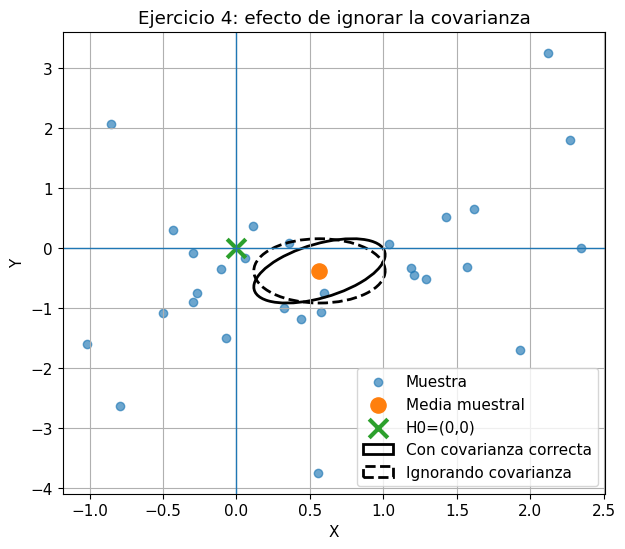

In [12]:

# Comparación geométrica de elipses: correcta vs diagonal
plt.figure(figsize=(7, 6))
ax = plt.gca()

plt.scatter(X[:, 0], X[:, 1], alpha=0.65, label="Muestra")
plt.scatter([xbar[0]], [xbar[1]], s=120, label="Media muestral")
plt.scatter([0], [0], marker="x", s=180, linewidths=3, label="H0=(0,0)")

confidence_ellipse_from_cov(
    mean=xbar,
    cov=Sigma / n,
    level=0.95,
    ax=ax,
    linewidth=2,
    label="Con covarianza correcta"
)

confidence_ellipse_from_cov(
    mean=xbar,
    cov=Sigma_diag / n,
    level=0.95,
    ax=ax,
    linewidth=2,
    linestyle="--",
    label="Ignorando covarianza"
)

plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Ejercicio 4: efecto de ignorar la covarianza")
plt.legend()
plt.show()



## Explicación conceptual

Ignorar la covarianza puede conducir a conclusiones erradas porque:

1. la variabilidad conjunta no se resume solo con las varianzas de $X$ y $Y$,
2. la correlación inclina y deforma la elipse de confianza,
3. $\Sigma^{-1}$ define la métrica correcta del problema,
4. si cambiamos esa métrica, cambiamos la prueba misma.

En lenguaje geométrico:

- con la matriz correcta, la distancia se mide en el sistema natural de dispersión del fenómeno;
- con la matriz diagonal, imponemos una geometría artificial, como si las variables no estuvieran relacionadas.



# Ejercicio 5. Caso con $\Sigma$ desconocida: estadístico $T^2$ de Hotelling

Cuando $\Sigma$ es desconocida, ya no podemos usar directamente:

$$
n(\bar{\mathbf Z}-\boldsymbol{\mu}_0)^\top \Sigma^{-1}(\bar{\mathbf Z}-\boldsymbol{\mu}_0),
$$

porque la matriz poblacional no está disponible.

Entonces la reemplazamos por la covarianza muestral $S$ y usamos:

$$
T^2
=
n(\bar{\mathbf Z}-\boldsymbol{\mu}_0)^\top
S^{-1}
(\bar{\mathbf Z}-\boldsymbol{\mu}_0).
$$

Para $p=2$ queda:

$$
T^2
=
n(\bar{\mathbf Z}-\boldsymbol{\mu}_0)^\top
S^{-1}
(\bar{\mathbf Z}-\boldsymbol{\mu}_0).
$$

La diferencia con el caso anterior no está en la forma algebraica visible, sino en la distribución de referencia.

Bajo normalidad multivariada:

$$
\frac{n-p}{p(n-1)}\,T^2 \sim F_{p,n-p}.
$$

Como aquí $p=2$, obtenemos:

$$
\frac{n-2}{2(n-1)}\,T^2 \sim F_{2,n-2}.
$$



## Regla de rechazo al nivel $\alpha=0.05$

Se rechaza $H_0$ si:

$$
\frac{n-p}{p(n-1)}\,T^2 > F_{p,n-p;0.95}.
$$

Equivalentemente:

$$
T^2 >
\frac{p(n-1)}{n-p}\,F_{p,n-p;0.95}.
$$

Con $p=2$ y $n=30$:

$$
T^2 >
\frac{2(29)}{28}F_{2,28;0.95}.
$$


In [13]:

# ==========================================
# Ejercicio 5
# ==========================================
p = 2
mu0 = np.array([0.0, 0.0])

T2 = n * (xbar - mu0).T @ np.linalg.inv(S) @ (xbar - mu0)
F_stat = ((n - p) / (p * (n - 1))) * T2

F_crit = f.ppf(0.95, p, n - p)
T2_crit = (p * (n - 1) / (n - p)) * F_crit
pval_hotelling = 1 - f.cdf(F_stat, p, n - p)

print(f"T^2 de Hotelling = {T2:.6f}")
print(f"Estadístico transformado a F = {F_stat:.6f}")
print(f"Valor crítico F_{{2,28;0.95}} = {F_crit:.6f}")
print(f"Umbral equivalente para T^2 = {T2_crit:.6f}")
print(f"p-value = {pval_hotelling:.6f}")


T^2 de Hotelling = 18.508982
Estadístico transformado a F = 8.935371
Valor crítico F_{2,28;0.95} = 3.340386
Umbral equivalente para T^2 = 6.919370
p-value = 0.000997



## Decisión e interpretación

Numéricamente se obtiene que el estadístico transformado supera el valor crítico de la distribución $F$, por lo que **se rechaza $H_0$**.

### Comparación conceptual con el caso de $\Sigma$ conocida

Hay dos diferencias fundamentales:

1. **Caso con $\Sigma$ conocida**  
   La incertidumbre poblacional está totalmente especificada.  
   Por eso la forma cuadrática se compara con una $\chi^2_2$.

2. **Caso con $\Sigma$ desconocida**  
   Debemos estimar la dispersión con $S$.  
   Eso introduce variabilidad extra, y por eso el objeto exacto ya no sigue una $\chi^2$ simple, sino que se corrige hacia la distribución $F$ mediante el estadístico $T^2$ de Hotelling.

### Lectura estratégica

La estructura lógica es la misma en ambos casos:

- medir qué tan lejos cae $\bar{\mathbf Z}$ del valor nulo,
- pero ajustando correctamente por la dispersión y la dependencia.

La diferencia real está en si esa dispersión es conocida o estimada.



# Ejercicio 6. Derivación conceptual de la forma cuadrática

Partimos de:

$$
\bar{\mathbf Z}\sim \mathcal N_2\left(\boldsymbol{\mu}, \frac{\Sigma}{n}\right).
$$

Queremos entender por qué aparece naturalmente la forma:

$$
n(\bar{\mathbf Z}-\boldsymbol{\mu})^\top \Sigma^{-1}(\bar{\mathbf Z}-\boldsymbol{\mu}),
$$

y por qué termina relacionada con una $\chi^2_2$.

---

## Paso 1. Definir el error de estimación

Sea

$$
\mathbf W=\bar{\mathbf Z}-\boldsymbol{\mu}.
$$

Entonces:

$$
\mathbf W \sim \mathcal N_2\left(\mathbf 0, \frac{\Sigma}{n}\right).
$$



## Paso 2. Introducir una raíz matricial

Como $\Sigma/n$ es simétrica definida positiva, existe una matriz $A$ tal que

$$
AA^\top=\frac{\Sigma}{n}.
$$

Esta matriz juega el papel de una desviación estándar matricial.



## Paso 3. Estandarizar

Definimos

$$
\mathbf U = A^{-1}\mathbf W.
$$

Como $\mathbf W$ es normal multivariada y $\mathbf U$ es una transformación lineal de $\mathbf W$, entonces $\mathbf U$ también es normal multivariada.



## Paso 4. Calcular media y covarianza de $\mathbf U$

La media es:

$$
E(\mathbf U)=E(A^{-1}\mathbf W)=A^{-1}E(\mathbf W)=A^{-1}\mathbf 0=\mathbf 0.
$$

La covarianza es:

$$
\operatorname{Cov}(\mathbf U)
=
A^{-1}\operatorname{Cov}(\mathbf W)(A^{-1})^\top.
$$

Como

$$
\operatorname{Cov}(\mathbf W)=\frac{\Sigma}{n}=AA^\top,
$$

se obtiene:

$$
\operatorname{Cov}(\mathbf U)
=
A^{-1}(AA^\top)(A^{-1})^\top
=
I.
$$

Por tanto:

$$
\mathbf U\sim \mathcal N_2(\mathbf 0,I).
$$



## Paso 5. Concluir la distribución chi-cuadrado

Si

$$
\mathbf U=
\begin{pmatrix}
U_1\\
U_2
\end{pmatrix}
\sim \mathcal N_2(\mathbf 0,I),
$$

entonces $U_1$ y $U_2$ son normales estándar independientes y, por tanto,

$$
U_1^2+U_2^2 \sim \chi^2_2.
$$

Es decir,

$$
\mathbf U^\top \mathbf U \sim \chi^2_2.
$$



## Paso 6. Reescribir $\mathbf U^\top \mathbf U$

Como $\mathbf U=A^{-1}\mathbf W$,

$$
\mathbf U^\top \mathbf U
=
\mathbf W^\top (A^{-1})^\top A^{-1}\mathbf W.
$$

Pero de $AA^\top=\Sigma/n$ se deduce que

$$
(A^{-1})^\top A^{-1}
=
(AA^\top)^{-1}
=
\left(\frac{\Sigma}{n}\right)^{-1}
=
n\Sigma^{-1}.
$$

Luego:

$$
\mathbf U^\top \mathbf U
=
\mathbf W^\top n\Sigma^{-1}\mathbf W.
$$

Y como $\mathbf W=\bar{\mathbf Z}-\boldsymbol{\mu}$, obtenemos:

$$
\mathbf U^\top \mathbf U
=
n(\bar{\mathbf Z}-\boldsymbol{\mu})^\top
\Sigma^{-1}
(\bar{\mathbf Z}-\boldsymbol{\mu}).
$$

Por tanto,

$$
n(\bar{\mathbf Z}-\boldsymbol{\mu})^\top
\Sigma^{-1}
(\bar{\mathbf Z}-\boldsymbol{\mu})
\sim \chi^2_2.
$$

Esta es la razón profunda por la que aparece la distancia de Mahalanobis en el test y en la región de confianza.


In [14]:

# Verificación numérica simple de la derivación con los datos observados
mu_demo = np.array([0.0, 0.0])
d = xbar - mu_demo

q = n * d.T @ np.linalg.inv(Sigma) @ d

print("Forma cuadrática evaluada en mu=(0,0):")
print(q)
print("\nBajo H0, esta cantidad se compara con una chi-cuadrado con 2 grados de libertad.")


Forma cuadrática evaluada en mu=(0,0):
23.955569013667933

Bajo H0, esta cantidad se compara con una chi-cuadrado con 2 grados de libertad.



# Ejercicio 7. Interpretación geométrica

Se pide explicar por qué la región de confianza es una **elipse** y no un rectángulo.

La región tiene la forma:

$$
n(\bar{\mathbf Z}-\boldsymbol{\mu})^\top
\Sigma^{-1}
(\bar{\mathbf Z}-\boldsymbol{\mu})
\le c.
$$

Esta es una ecuación cuadrática en dos dimensiones.  
Las curvas de nivel de una forma cuadrática definida positiva son elipses.

---

## Papel de $\Sigma^{-1}$

La matriz $\Sigma^{-1}$ define la métrica del problema.  
No estamos midiendo distancia euclidiana ordinaria, sino distancia de Mahalanobis.

Eso significa que la separación entre puntos depende de:

- la escala de cada variable,
- y la dependencia entre ellas.



## Efecto de la correlación

Si las variables están correlacionadas, la nube natural del fenómeno aparece inclinada.  
En consecuencia, la elipse también se inclina.

Si la covarianza fuera cero, la elipse estaría alineada con los ejes coordenados.  
Con covarianza no nula, aparece una rotación.



## Papel de autovalores y autovectores

La matriz $\Sigma$ tiene autovalores y autovectores.

- Los **autovectores** indican las direcciones principales de dispersión.
- Los **autovalores** indican cuánto se dispersa la nube en cada una de esas direcciones.

Por eso:

- la orientación de la elipse la determinan los autovectores,
- y la longitud de sus semiejes la determinan los autovalores.


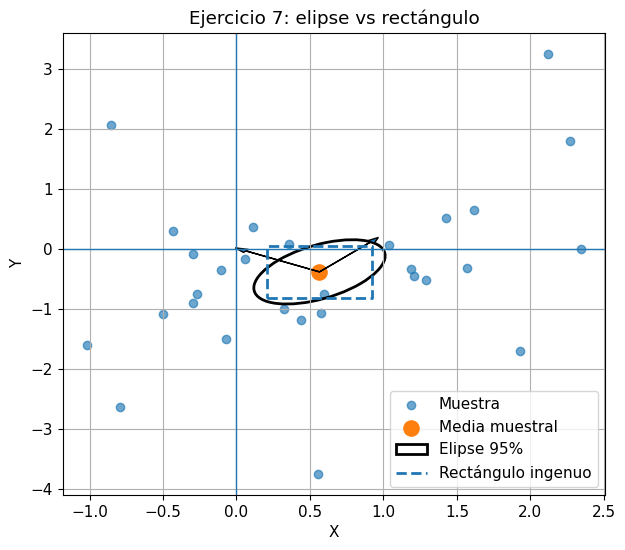

In [15]:

# ==========================================
# Ejercicio 7: gráfico geométrico
# ==========================================
eigvals, eigvecs = np.linalg.eigh(Sigma)
order = eigvals.argsort()[::-1]
eigvals = eigvals[order]
eigvecs = eigvecs[:, order]

plt.figure(figsize=(7, 6))
ax = plt.gca()

plt.scatter(X[:, 0], X[:, 1], alpha=0.65, label="Muestra")
plt.scatter([xbar[0]], [xbar[1]], s=120, label="Media muestral")

confidence_ellipse_from_cov(
    mean=xbar,
    cov=Sigma / n,
    level=0.95,
    ax=ax,
    linewidth=2,
    label="Elipse 95%"
)

# Rectángulo ingenuo usando márgenes marginales al 95%
marg_x = np.sqrt(chi2.ppf(0.95, 1) * Sigma[0, 0] / n)
marg_y = np.sqrt(chi2.ppf(0.95, 1) * Sigma[1, 1] / n)

x_left = xbar[0] - marg_x
x_right = xbar[0] + marg_x
y_bottom = xbar[1] - marg_y
y_top = xbar[1] + marg_y

plt.plot([x_left, x_right, x_right, x_left, x_left],
         [y_bottom, y_bottom, y_top, y_top, y_bottom],
         linestyle="--", linewidth=2, label="Rectángulo ingenuo")

# Autovectores
scale = 0.7
for j in range(2):
    vec = eigvecs[:, j]
    plt.arrow(
        xbar[0], xbar[1],
        scale * vec[0], scale * vec[1],
        head_width=0.06, length_includes_head=True
    )

plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Ejercicio 7: elipse vs rectángulo")
plt.legend()
plt.show()



## Explicación final

La región de confianza no es un rectángulo porque el problema no se descompone correctamente en dos intervalos independientes.

Un rectángulo supondría, en esencia, que:

- cada coordenada se trata por separado,
- y que la dependencia entre variables no importa.

Eso es falso cuando existe covarianza.

La elipse, en cambio, sí representa correctamente la geometría conjunta del problema:

- se adapta a la escala,
- se adapta a la correlación,
- y delimita puntos con igual distancia de Mahalanobis al centro.



# Cierre general del taller

## Qué debe quedar firme

1. El parámetro de interés es el vector:

$$
\boldsymbol{\mu}=
\begin{pmatrix}
\mu_x\\
\mu_y
\end{pmatrix}.
$$

2. La inferencia correcta no mira $X$ y $Y$ por separado, sino conjuntamente.

3. Cuando $\Sigma$ es conocida, la cantidad central es:

$$
n(\bar{\mathbf Z}-\boldsymbol{\mu}_0)^\top
\Sigma^{-1}
(\bar{\mathbf Z}-\boldsymbol{\mu}_0),
$$

y bajo $H_0$ sigue una $\chi^2_2$.

4. La región de confianza conjunta tiene forma de elipse porque proviene de una forma cuadrática.

5. A mayor $n$, menor incertidumbre y elipses más pequeñas.

6. Ignorar la covarianza distorsiona la métrica del problema y puede llevar a decisiones equivocadas.

7. Si $\Sigma$ es desconocida, el reemplazo correcto es el estadístico $T^2$ de Hotelling, conectado con una distribución $F$.

---

## Idea profunda

La inferencia multivariada no es una suma de inferencias univariadas.  
Su núcleo está en la **geometría de la covarianza**.

Ese es el punto verdaderamente importante de todo el taller.
